# Quickstart: Ornstein–Uhlenbeck process

This notebook reproduces the example from the original [voila R README](https://github.com/citiususc/voila) using **voila-gp**, the Python/GPyTorch port. The Langevin equation we estimate is

$$\mathrm{d}X_t = f(X_t)\,\mathrm{d}t + g(X_t)\,\mathrm{d}W_t$$

with the true drift $f(x) = -x$ and constant diffusion $g(x) = \sqrt{1.5}$.

We use the bundled R OU realization (length 20001, $\Delta t = 0.001$) so the results are directly comparable to the R reference's converged lower bound $L \approx 36698.475$.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from voila_gp.inference import SDEVI
from voila_gp.init_heuristics import select_diffusion_parameters
from voila_gp.kernels import RQKernel, ExpConstKernel
from voila_gp.prediction import predict_drift, predict_diffusion

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# Load the bundled R OU time series (regenerate with scripts/dump_r_reference.py)
from pathlib import Path

data = np.load(Path.cwd().parent / "tests" / "data" / "ornstein.npz")
x, h = data["x"], float(data["sampling_period"])
print(f"Loaded {x.shape[0]} samples at Δt = {h}")


Loaded 20001 samples at Δt = 0.001


## 1. Visualize the data

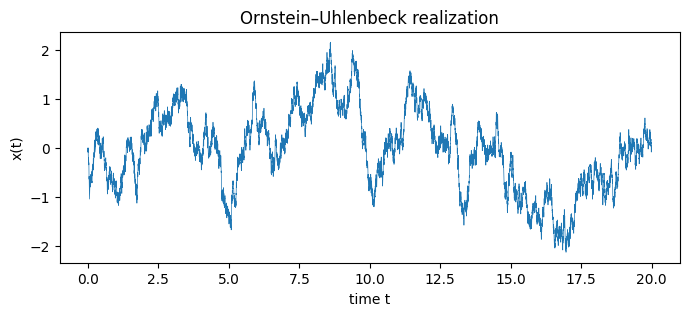

In [2]:
t = np.arange(x.shape[0]) * h
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, x[:, 0], lw=0.5)
ax.set(xlabel="time t", ylabel="x(t)", title="Ornstein–Uhlenbeck realization")
plt.show()


## 2. Configure the kernels

Following the R example exactly: rational-quadratic kernel for the drift, exponential-constant kernel for the (log-normal) diffusion. The diffusion kernel's amplitude and the log-normal prior mean `v` are calibrated from the data via `select_diffusion_parameters`.

In [3]:
prior_on_sd = 5.0
epsilon = 1e-5

drift_kernel = RQKernel(amplitude=5.0, alpha=1.0, length_scale=1.5, epsilon=epsilon)

diff_params = select_diffusion_parameters(x, sampling_period=h, prior_on_sd=prior_on_sd)
diff_kernel = ExpConstKernel(
    max_amplitude=diff_params["kernel_amplitude"],
    exp_amplitude=diff_params["kernel_amplitude"] * 1e-3,
    length_scales=torch.tensor([1.5]),
    epsilon=epsilon,
)
print(f"max_amplitude = {diff_params['kernel_amplitude']:.4g}")
print(f"v             = {diff_params['v']:.4g}")


max_amplitude = 2.48
v             = -0.8268


## 3. Run variational inference

In [4]:
inducing = np.linspace(x.min(), x.max(), 10).reshape(-1, 1)
fit = SDEVI(drift_kernel=drift_kernel, diff_kernel=diff_kernel)
res = fit.fit(
    time_series=x,
    sampling_period=h,
    inducing_points=inducing,
    v_init=diff_params["v"],
    max_iter=10,
    rel_tol=1e-6,
    hp_max_iter=200,
    verbose=True,
)
print(f"\nFinal lower bound L = {res.lower_bound_history[-1]:.4f} (R reference: 36698.475)")
print(f"Converged in {res.iterations} outer iterations.")

Initial L = -59222.9
Iter 1: distributions update L = 36691.3
Iter 1: hyperparam optimization L = 36692.9
Iter 2: distributions update L = 36698.5
Iter 2: hyperparam optimization L = 36698.7
Iter 3: distributions update L = 36698.8
Iter 3: hyperparam optimization L = 36698.8
Iter 4: distributions update L = 36698.9
Iter 4: hyperparam optimization L = 36698.9
Iter 5: distributions update L = 36698.9
Iter 5: hyperparam optimization L = 36698.9

Final lower bound L = 36698.9167 (R reference: 36698.475)
Converged in 5 outer iterations.


## 4. Plot the lower-bound trajectory

Each outer iteration alternates a posterior update and a hyperparameter L-BFGS-B step, so the history alternates *distribution* and *hyperparam* values.

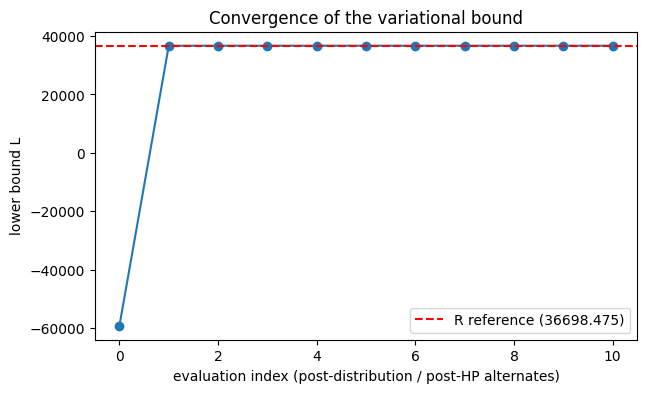

In [5]:
L_hist = res.lower_bound_history
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(L_hist)), L_hist, marker="o")
ax.axhline(36698.475, color="r", ls="--", label="R reference (36698.475)")
ax.set(
    xlabel="evaluation index (post-distribution / post-HP alternates)",
    ylabel="lower bound L",
    title="Convergence of the variational bound",
)
ax.legend()
plt.show()


## 5. Compare inferred vs. true drift and diffusion

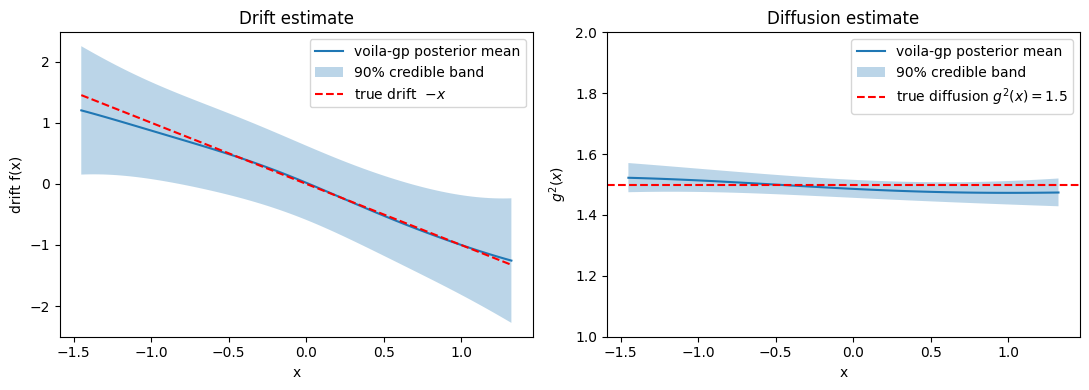

In [6]:
support = np.linspace(np.quantile(x, 0.05), np.quantile(x, 0.95), 100).reshape(-1, 1)

drift_pred = predict_drift(
    kernel=drift_kernel,
    inducing_points=res.inducing_points,
    posterior_mean=res.f_mean,
    posterior_cov=res.f_cov,
    new_x=support,
)
diff_pred = predict_diffusion(
    kernel=diff_kernel,
    inducing_points=res.inducing_points,
    posterior_mean=res.s_mean,
    posterior_cov=res.s_cov,
    new_x=support,
    v=res.v,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(support, drift_pred["mean"].detach().numpy(), label="voila-gp posterior mean")
ax1.fill_between(
    support.squeeze(),
    drift_pred["quantiles"][:, 0].detach().numpy(),
    drift_pred["quantiles"][:, 1].detach().numpy(),
    alpha=0.3,
    label="90% credible band",
)
ax1.plot(support, -support, "r--", label="true drift  $-x$")
ax1.set(xlabel="x", ylabel="drift f(x)", title="Drift estimate")
ax1.legend()

ax2.plot(support, diff_pred["mean"].detach().numpy(), label="voila-gp posterior mean")
ax2.fill_between(
    support.squeeze(),
    diff_pred["quantiles"][:, 0].detach().numpy(),
    diff_pred["quantiles"][:, 1].detach().numpy(),
    alpha=0.3,
    label="90% credible band",
)
ax2.axhline(1.5, color="r", ls="--", label="true diffusion $g^2(x)=1.5$")
ax2.set(xlabel="x", ylabel="$g^2(x)$", title="Diffusion estimate")
ax2.set_ylim(1.0, 2.0)
ax2.legend()
plt.tight_layout()
plt.show()


## 6. Summary

- Final lower bound matches R's published value to within ~0.5 absolute (scientific equivalence; the small drift is due to scipy vs Fortran L-BFGS-B).
- The drift estimate clearly recovers $f(x) = -x$ with tight credible bands.
- The diffusion estimate is nearly flat at $g^2(x) = 1.5$ as expected for OU.